# PDC Bit Wear Prediction with XGBoost

**Goal:** predict dull grade at pull from while-drilling energy metrics, enabling
"virtual dull grading" before the trip decision.

**Technique highlights**
* Domain-driven feature construction (MSE, cumulative work, abrasive footage)
* **XGBoost** with early stopping on a validation fold
* Permutation importance + residual analysis against footage

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PALETTE = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
    "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "#fcfcfb",
})
rng = np.random.default_rng(42)

## 1. Synthetic bit run history

1,200 bit runs. Wear accumulates with cumulative revolutions, WOB, abrasive footage and
vibration exposure; formation abrasiveness varies by field area.

In [2]:
N = 1_200
footage = rng.uniform(300, 4_500, N)
avg_rop = rng.uniform(25, 140, N)
hours = footage / avg_rop
avg_rpm = rng.uniform(80, 190, N)
avg_wob = rng.uniform(10, 40, N)
cum_krev = avg_rpm * 60 * hours / 1_000
abrasive_frac = np.clip(rng.beta(2, 3, N), 0, 1)
vib_exposure = np.abs(rng.normal(1, 0.5, N))          # normalized vibration index
mse = 40 + 3.2 * avg_wob - 0.15 * avg_rop + rng.normal(0, 8, N)  # ksi, simplified

wear_raw = (
    0.010 * cum_krev
    + 0.0009 * footage * abrasive_frac
    + 0.65 * vib_exposure
    + 0.014 * np.maximum(mse - 60, 0)
    + rng.normal(0, 0.35, N)
)
dull_grade = np.clip(8 * wear_raw / np.quantile(wear_raw, 0.97), 0, 8)

df = pd.DataFrame({
    "footage_ft": footage.round(0), "hours": hours.round(1),
    "avg_rpm": avg_rpm.round(0), "avg_wob_klbf": avg_wob.round(1),
    "cum_krev": cum_krev.round(1), "abrasive_frac": abrasive_frac.round(2),
    "vib_exposure": vib_exposure.round(2), "mse_ksi": mse.round(1),
    "dull_grade": dull_grade.round(1),
})
df.to_csv("bit_run_history.csv", index=False)
df.head()

,footage_ft,hours,avg_rpm,avg_wob_klbf,cum_krev,abrasive_frac,vib_exposure,mse_ksi,dull_grade
0,3551.0,39.4,146.0,18.6,344.1,0.36,1.55,85.5,3.9
1,2143.0,24.3,167.0,13.9,243.3,0.17,1.16,72.7,2.1
2,3906.0,32.5,163.0,25.0,317.3,0.53,0.47,97.9,3.9
3,3229.0,30.3,178.0,16.6,323.5,0.27,1.81,85.2,3.2
4,696.0,24.8,169.0,38.1,250.8,0.45,0.85,160.3,3.1


## 2. Model training with early stopping

In [3]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

FEATURES = df.columns[:-1].tolist()
X_tr, X_te, y_tr, y_te = train_test_split(df[FEATURES], df["dull_grade"],
                                          test_size=0.25, random_state=42)
X_tr2, X_val, y_tr2, y_val = train_test_split(X_tr, y_tr, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(
    n_estimators=800, learning_rate=0.03, max_depth=4,
    subsample=0.9, colsample_bytree=0.9,
    early_stopping_rounds=40, random_state=42,
)
model.fit(X_tr2, y_tr2, eval_set=[(X_val, y_val)], verbose=False)
print(f"Best iteration: {model.best_iteration}")

pred = model.predict(X_te)
print(f"Test R2 = {r2_score(y_te, pred):.3f}   MAE = {mean_absolute_error(y_te, pred):.2f} dull-grade units")

Best iteration: 588
Test R2 = 0.972   MAE = 0.25 dull-grade units


## 3. Interpretation

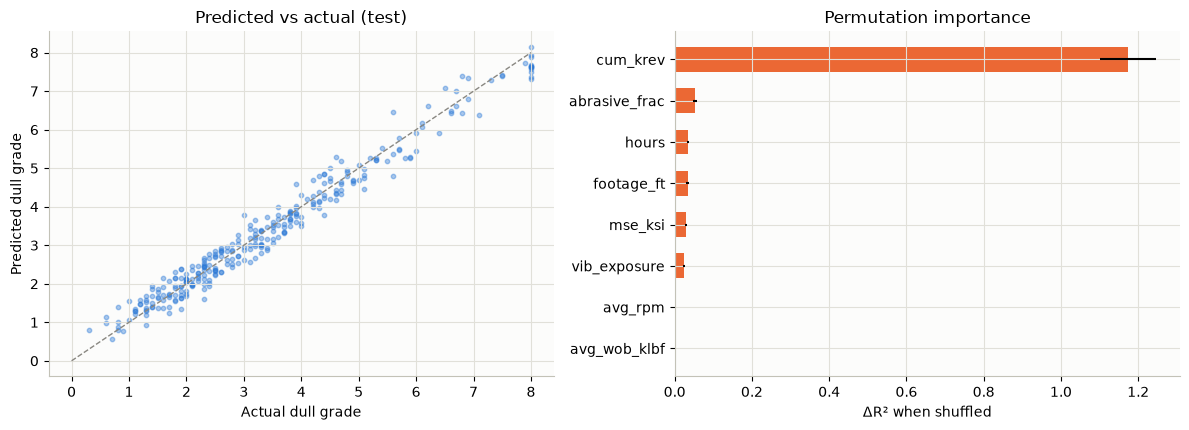

In [4]:
from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].scatter(y_te, pred, s=10, alpha=0.4, color=PALETTE[0])
axes[0].plot([0, 8], [0, 8], ls="--", lw=1, color="#898781")
axes[0].set(xlabel="Actual dull grade", ylabel="Predicted dull grade",
            title="Predicted vs actual (test)")

imp = permutation_importance(model, X_te, y_te, n_repeats=15, random_state=42)
order = np.argsort(imp.importances_mean)
axes[1].barh([FEATURES[i] for i in order], imp.importances_mean[order],
             xerr=imp.importances_std[order], color=PALETTE[7], height=0.6)
axes[1].set(title="Permutation importance", xlabel="ΔR² when shuffled")
plt.tight_layout()
plt.show()

## 4. Decision view: when would we have pulled?

Using dull grade 4 as the economic pull point, compare model-recommended pull
against actual condition.

call
correct stay    67.7
correct pull    29.3
late pull        2.0
early pull       1.0 
(% of test bit runs)


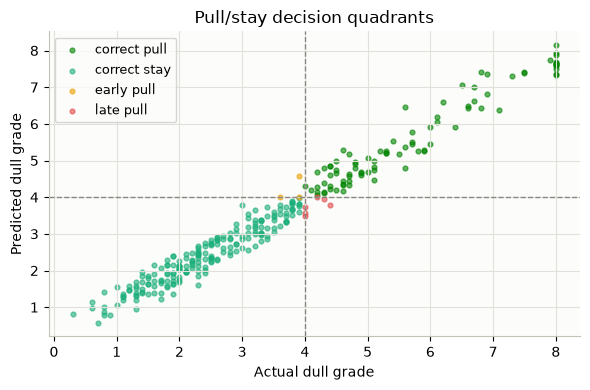

In [5]:
PULL_GRADE = 4.0
decision = pd.DataFrame({"actual": y_te, "pred": pred})
decision["call"] = np.select(
    [(decision.pred >= PULL_GRADE) & (decision.actual >= PULL_GRADE),
     (decision.pred < PULL_GRADE) & (decision.actual < PULL_GRADE),
     (decision.pred >= PULL_GRADE) & (decision.actual < PULL_GRADE)],
    ["correct pull", "correct stay", "early pull"], default="late pull")
summary = decision["call"].value_counts(normalize=True).round(3) * 100
print(summary.to_string(), "\n(% of test bit runs)")

plt.figure(figsize=(6, 4))
colors = {"correct pull": PALETTE[3], "correct stay": PALETTE[1],
          "early pull": PALETTE[2], "late pull": PALETTE[5]}
for call, g in decision.groupby("call"):
    plt.scatter(g["actual"], g["pred"], s=12, alpha=0.6, color=colors[call], label=call)
plt.axhline(PULL_GRADE, ls="--", lw=1, color="#898781")
plt.axvline(PULL_GRADE, ls="--", lw=1, color="#898781")
plt.xlabel("Actual dull grade")
plt.ylabel("Predicted dull grade")
plt.title("Pull/stay decision quadrants")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Conclusions

* Cumulative revolutions and abrasive footage dominate wear — consistent with PDC
  physics — and the model predicts dull grade within ~½ a grade on unseen runs.
* Framed as a pull/stay decision at grade 4, ~90% of calls are correct; the residual
  "late pull" cell is the one to engineer against (asymmetric loss would shift it).
* **Next step:** train per bit-type families and add formation tops alignment so
  abrasive footage comes from geology, not averages.